<h2>What is difference between Process and Threads</h2>

In [ ]:
x = 10
y = 20
z = x + y


<p>When we execute python app.py command Python Interpretator CPython compiles app.py into machine code</p>
<p>And the OS needs to load the program into the memory RAM to run the program</p>


<p>Once the OS loads the program to memory, it moves the instructions to the CPU for execution via bus</p>
<p>In general the OS moves the instructions to a queque also known as a pipline, Then the COU will execute the instructions from the pipeline</p>
<p style="font-weight: bold;">By defenition a process is an instance of a program running on a computer. And a thread is a unit of execution within a process</p>

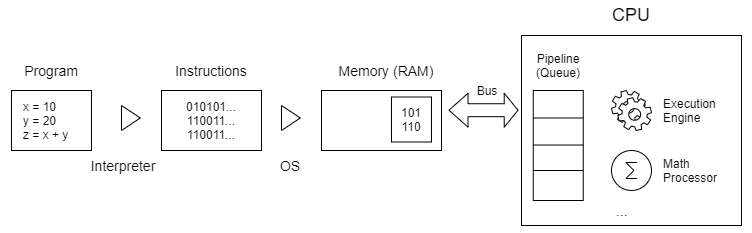

<p>When program has multiple process it is called <b>MULTIPROCESSING</b> If program has multiple threads it's called <b>MULTITHREADING</b></p>

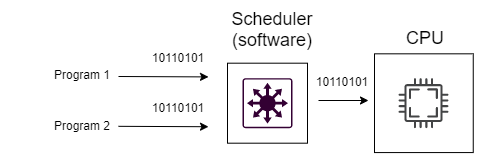

<p>
    In the past a CPU has only one core. In other
    words it can run only a single process at one
    time. To execute multiple processes "at the 
    same time" the OS uses a software component
    called a <b>scheduler</b>
</p>
<p>
    The scheduler switches between process so quickly
    around 1 ms that is creates the illusion of 
    the computer being able to execute multiple
    process simultaneously
</p>

<h4>Multiple Process</h4>

<p>
    Today the CPU often has multiple cores
    e.g. two cores and four cores

    The number of cores will determine the number
    of process that the CPU can execute simultaneously
    Generally the more cores the CPU has, the more
    processes it can truly execute simultaneously
</p>

<h3>CPU bound VS I/O bound tasks</h3>
<p>
    In general programs deal with two types of tasks:
    I/O bound or CPU bound
</p>

<ul>
    <li>
        I/O bound taks spend more time doing 
        I/O than doing compulations. The typical
        examples of I/O bound taks are network reqeusts
        database connections and file reading/writing
    </li>
    <li>
        In contrast CPU-bound tasks uses more time compulations
        than generating I/O requests The typical examples of CPU 
        bound tasks are matrix multiplication finding prime numbers
        video compression and video streaming
    </li>
</ul>

<h3>Single-Thread applications</h3>

In [1]:
from time import sleep, perf_counter

def task():
    print("Starting the task: ")
    sleep(1)
    print("done")

start_time = perf_counter()

task()
task()

end_time = perf_counter()

print(f"It took {end_time - start_time: 0.2f} seconds to complete")

Starting the task: 
done
Starting the task: 
done
It took  2.00 seconds to complete


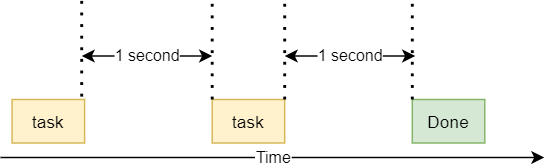

<h3>Using Python threading to develop a multi-threaded program example</h3>

In [6]:
from time import sleep, perf_counter
from threading import Thread

def task():
    print("The task is started:")
    sleep(1)
    print("Task end")

start_time = perf_counter()

thread1 = Thread(target=task)
thread2 = Thread(target=task)

thread1.start()
thread2.start()

# thread1.join()
# thread2.join()


end_time = perf_counter()

print(f"It took {end_time - start_time :0.2f} to complete")


The task is started:
The task is started:
It took 0.00 to complete


Task end
Task end


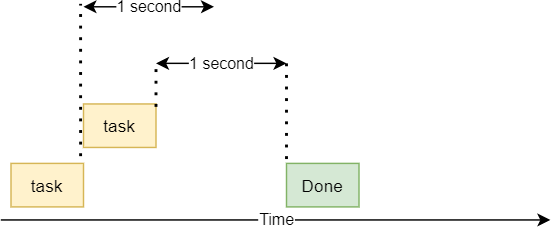

In [5]:
from time import sleep, perf_counter
from threading import Thread


def task(id):
    print(f"The task with id={id} is started")
    sleep(1)
    print(f"The task with id={id} ended")


start_time = perf_counter()

threads = []

for i in range(1, 11):
    t = Thread(target=task, args=(i,))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

end_time = perf_counter()

print(f'It took {end_time- start_time: 0.2f} second(s) to complete.')

The task with id=1 is started
The task with id=2 is started
The task with id=3 is started
The task with id=4 is started
The task with id=5 is started
The task with id=6 is started
The task with id=7 is started
The task with id=8 is started
The task with id=9 is started
The task with id=10 is started
The task with id=1 ended
The task with id=2 ended
The task with id=3 ended
The task with id=4 ended
The task with id=5 ended
The task with id=6 ended
The task with id=8 ended
The task with id=9 ended
The task with id=7 ended
The task with id=10 ended
It took  1.00 second(s) to complete.


<p>
    When a Python program starts it has thread called the main thread. Sometimes you
    want to offload the I/O bound tasks to a new thread to execute them concurrently.
    To do that you use the built-in threading module
</p>


In [ ]:
import urllib

class HttpRequestThread(Thread):
    def __init__(self, url: str) -> None:
        super().__init__()
        self.url = url

    def run(self) -> None:
        print(f'Checking {self.url} ...')
        try:
            response = urllib.request.urlopen(self.url)
            print(response.code)
        except urllib.error.HTTPError as e:
            print(e.code)
        except urllib.error.URLError as e:
            print(e.reason)

ModuleNotFoundError: No module named 'url'